## Simulating multiple datasets in parallel for parameter recovery

In [2]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import spearmanr
from fastprogress import progress_bar
from jax import lax, vmap
from jax.nn import sigmoid
from jaxtyping import Float, Array
from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

## Implement the model


In [3]:
A_MAX = 0.99

In [4]:
class HierarchicalBernoulliLDS(eqx.Module):
    r"""
    Implementation of the model.
    """
    # Parameters of prior distributions
    w_0       : Float[Array, "num_inputs"]   # mean normal for input weights
    log_nu_w  : Float[Array, "num_inputs"]   # sd normal for input weights
    logit_a_0 : Float = 10.0                 # mean truncated normal for autoregressive coefficients (latent states) in unconstrained form (allows HMC)
    log_nu_a  : Float = -1.0                 # sd truncated normal for autoregressive coefficient (latent states) in unconstrained form
    log_alpha : Float = 1.0                  # shape of inverse gamma prior for sigmasq of latent states
    log_beta  : Float = 1.0                  # scale of inverse gamma prior for sigmasq of latent states
    log_nu_mu0 : Float = -1.0                # sd normal for mu0

    def __init__(self, a_0, nu_a, w_0, nu_w, alpha, beta, nu_mu0):
        self.logit_a_0 = jnp.log(a_0 / (1 - a_0))
        self.log_nu_a = jnp.log(nu_a)
        self.w_0 = w_0
        self.log_nu_w = jnp.log(nu_w)
        self.log_alpha = jnp.log(alpha)
        self.log_beta = jnp.log(beta)
        self.log_nu_mu0 = jnp.log(nu_mu0)

    def sample(self,
               key,
               inputs : Float[Array, "num_subjects num_trials num_inputs"]
               ):
        r"""
        Draw a sample from the generative model.
        """
        num_subjects, num_trials, num_inputs = inputs.shape
        assert num_inputs == self.w_0.shape[0]

        def _sample_one(key, u_i):
            k1, k2, k3, k4, k5, k6, k7 = jr.split(key, 7)

            # Sample per trial parameters
            w_i = tfd.Normal(self.w_0, jnp.exp(self.log_nu_w)).sample(seed=k1)
        
            a_i = tfd.TruncatedNormal(sigmoid(self.logit_a_0),
                                      jnp.exp(self.log_nu_a),
                                      0.0, A_MAX).sample(seed=k2)

            sigmasq_i = tfd.InverseGamma(jnp.exp(self.log_alpha),
                                 jnp.exp(self.log_beta)).sample(seed=k3)

            mu0_i = tfd.Normal(0, jnp.exp(self.log_nu_mu0)).sample(seed=k2)
            
            sigmasq0_i = 1.0
            b_i = mu0_i * (1 - a_i)
            
            # Sample latent states starting at the stationary distribution
            # Stationary covariance is \sigma_0^2 = \sigma^2 / (1 - a^2)
            x_i0 = tfd.Normal(mu0_i, jnp.sqrt(sigmasq0_i)).sample(seed=k5)
  
            def _step(x_it, key):
                x_itp1 = tfd.Normal(a_i * x_it + b_i, jnp.sqrt(sigmasq_i)).sample(seed=key)
                return x_itp1, x_it
            _, x_i = lax.scan(_step, x_i0, jr.split(k6, num_trials))

            # Sample emissions
            y_i = tfd.Bernoulli(x_i + u_i @ w_i).sample(seed=k7)
            return dict(a=a_i, mu0=mu0_i, w=w_i, sigmasq=sigmasq_i), x_i, y_i

        return vmap(_sample_one)(jr.split(key, num_subjects), inputs)


    def log_prob(self,
                 emissions : Float[Array, "num_subjects num_trials"],
                 masks : Float[Array, "num_subjects num_trials"],
                 states : Float[Array, "num_subjects num_trials"],
                 inputs : Float[Array, "num_subjects num_trials num_inputs"],
                 params : dict):
        def _single_lp(y_i, m_i, x_i, u_i, params_i):
            a_i = params_i["a"]
            mu0_i = params_i["mu0"]
            w_i = params_i["w"]
            sigmasq_i = params_i["sigmasq"]
            sigmasq0_i = 1.0

            # Derive b_i from mu0_i and a_i
            b_i = mu0_i * (1 - a_i)

            # \log p(\theta_i | \eta)
            lp_i = tfd.TruncatedNormal(sigmoid(self.logit_a_0),
                                       jnp.exp(self.log_nu_a),
                                       0.0, A_MAX).log_prob(a_i)
            lp_i += tfd.Normal(0.0, jnp.exp(self.log_nu_mu0)).log_prob(mu0_i) # CHANGED THIS, WAS ORIGINALLY N(0,1)
            lp_i += tfd.Normal(self.w_0, jnp.exp(self.log_nu_w)).log_prob(w_i)
            lp_i += tfd.InverseGamma(jnp.exp(self.log_alpha),
                                     jnp.exp(self.log_beta)).log_prob(sigmasq_i)

            # \log p(x_i | \theta_i)
            lp_i += tfd.Normal(mu0_i, jnp.sqrt(sigmasq0_i)).log_prob(x_i[0])
            lp_i += tfd.Normal(a_i * x_i[:-1] + b_i, jnp.sqrt(sigmasq_i)).log_prob(x_i[1:]).sum()

            # \log p(y_i | x_i, u_i, \theta_i)
            lp_i += jnp.sum(m_i * tfd.Bernoulli(x_i + u_i @ w_i).log_prob(y_i)) # m_i is mask (if 0 then just sum 0)
            return lp_i

        return vmap(_single_lp)(emissions, masks, states, inputs, params).sum()


## Helper function for sampling linear Gaussian ssm

In [5]:
from jax.scipy.linalg import solve_triangular

def lds_info_filter(J_diag, J_lower_diag, h):
    """ Information form filtering for a linear Gaussian dynamical system.
    """
    # extract dimensions
    num_trials, dim, _ = J_diag.shape

    # Pad the L's with one extra set of zeros for the last predict step
    J_lower_diag_pad = jnp.concatenate((J_lower_diag, jnp.zeros((1, dim, dim))), axis=0)

    def marginalize(carry, t):
        Jp, hp, lp = carry

        # Condition
        Jc = J_diag[t] + Jp
        hc = h[t] + hp

        # Predict (using Cholesky)
        sqrt_Jc = jnp.linalg.cholesky(Jc)
        trm1 = solve_triangular(sqrt_Jc, hc, lower=True)
        trm2 = solve_triangular(sqrt_Jc, J_lower_diag_pad[t].T, lower=True)
        log_Z = 0.5 * dim * jnp.log(2 * jnp.pi)
        log_Z += -jnp.sum(jnp.log(jnp.diag(sqrt_Jc)))  # sum these terms only to get approx log|J|
        log_Z += 0.5 * jnp.dot(trm1.T, trm1)
        Jp = -jnp.dot(trm2.T, trm2)
        hp = -jnp.dot(trm2.T, trm1)

        # Alternative predict step:
        # log_Z = 0.5 * dim * np.log(2 * np.pi)
        # log_Z += -0.5 * np.linalg.slogdet(Jc)[1]
        # log_Z += 0.5 * np.dot(hc, np.linalg.solve(Jc, hc))
        # Jp = -np.dot(J_lower_diag_pad[t], np.linalg.solve(Jc, J_lower_diag_pad[t].T))
        # hp = -np.dot(J_lower_diag_pad[t], np.linalg.solve(Jc, hc))

        new_carry = Jp, hp, lp + log_Z
        return new_carry, (Jc, hc)

    # Initialize
    Jp0 = jnp.zeros((dim, dim))
    hp0 = jnp.zeros((dim,))
    (_, _, log_Z), (filtered_Js, filtered_hs) = \
        lax.scan(marginalize, (Jp0, hp0, 0), jnp.arange(num_trials))
    return log_Z, filtered_Js, filtered_hs

def _sample_info_gaussian(key, J, h, sample_shape=()):
    # TODO: avoid inversion.
    # see https://github.com/mattjj/pybasicbayes/blob/master/pybasicbayes/util/stats.py#L117-L122
    # L = np.linalg.cholesky(J)
    # x = np.random.randn(h.shape[0])
    # return scipy.linalg.solve_triangular(L,x,lower=True,trans='T') \
    #     + dpotrs(L,h,lower=True)[0]
    cov = jnp.linalg.inv(J)
    loc = jnp.einsum("...ij,...j->...i", cov, h)
    return tfp.distributions.MultivariateNormalFullCovariance(
        loc=loc, covariance_matrix=cov).sample(sample_shape=sample_shape, seed=key)


def lds_info_sample(key, J_diag, J_lower_diag, h):
        num_trials = J_diag.shape[0]
        log_Z, filtered_Js, filtered_hs = lds_info_filter(J_diag, J_lower_diag, h)

        def _step(carry, inpt):
            x_next = carry
            key, Jf, hf, L = inpt

            # Condition on the next observation
            Jc = Jf
            hc = hf - jnp.einsum('i,ij->j', x_next, L)

            # Sample the gaussian
            x = _sample_info_gaussian(key, Jc, hc)
            return x, x

        # Initialize with sample of last timestep and sample in reverse
        keys = jr.split(key, num_trials)
        x_T = _sample_info_gaussian(keys[-1], filtered_Js[-1], filtered_hs[-1])
        args = (keys[:-1], filtered_Js[:-1], filtered_hs[:-1], J_lower_diag)
        _, x = lax.scan(_step, x_T, args, reverse=True)

        # Append the last sample
        return jnp.vstack((x, x_T))

## Implement the Gibbs sampler

In [6]:
def gibbs_step_states(key,
                      emissions : Float[Array, "num_subjects num_trials"],
                      masks: Float[Array, "num_subjects num_trials"],
                      inputs : Float[Array, "num_subjects num_trials num_inputs"],
                      pg_samples : Float[Array, "num_subjects num_trials"],
                      params: dict):
    """
    Draw a sample of the latent states from their conditional distribution
    given emissions, inputs, auxiliary PG variables, and parameters.
    """
    N, T, D = inputs.shape
    def _sample_one(key, y_i, m_i, u_i, pg_i, params_i):
        w_i = params_i["w"]
        a_i = params_i["a"]
        mu0_i = params_i["mu0"]
        sigmasq_i = params_i["sigmasq"]
        sigmasq0_i = 1.0

        # Compute b from mu0 and a
        b_i = mu0_i * (1 - a_i)

        # Compute the LDS natural params
        J_diag = (pg_i * m_i)                                   # (T,)
        J_diag = J_diag.at[0].add(1 / sigmasq0_i)
        J_diag = J_diag.at[:-1].add(a_i**2 / sigmasq_i)
        J_diag = J_diag.at[1:].add(1. / sigmasq_i)

        # lower diagonal blocks of precision matrix
        J_lower_diag = -a_i / sigmasq_i * jnp.ones(T - 1)       # (T-1,)

        # linear potential (precision-weighted mean h)
        h = (y_i - pg_i * (u_i @ w_i) - 0.5) * m_i              # (T,)

        # Incorporate the bias
        h = h.at[0].add(mu0_i / sigmasq0_i)
        h = h.at[:-1].add(-b_i * a_i / sigmasq_i)
        h = h.at[1:].add(b_i / sigmasq_i)

        # Run the information form sampling algorithm
        x_i = lds_info_sample(key,
                              J_diag[:, None, None],
                              J_lower_diag[:, None, None],
                              h[:, None])[:, 0]                 # (T,)

        return x_i

    return vmap(_sample_one)(jr.split(key, N),
                             emissions,
                             masks,
                             inputs,
                             pg_samples,
                             params)

### Local Parameter Updates

In [7]:
def gibbs_step_local_params(key,
                            emissions : Float[Array, "num_subjects num_trials"],
                            masks: Float[Array, "num_subjects num_trials"],
                            states: Float[Array, "num_subjects num_trials"],
                            inputs : Float[Array, "num_subjects num_trials num_inputs"],
                            pg_samples : Float[Array, "num_subjects num_trials"],
                            params: dict,
                            model : HierarchicalBernoulliLDS,
                            ):
    r"""
    Perform one Gibbs step to update the local parameters.
    """
    num_subjects, num_trials, num_inputs = inputs.shape
    a_0 = sigmoid(model.logit_a_0)
    nu_a = jnp.exp(model.log_nu_a)
    w_0 = model.w_0
    nu_w = jnp.exp(model.log_nu_w)
    nu_mu0 = jnp.exp(model.log_nu_mu0)

    def _sample_one(key, y_i, m_i, x_i, u_i, pg_i, params_i):
        k1, k2, k3, k4 = jr.split(key, 4)

        # Gibbs sample the input weights
        J_w = 1.0 / nu_w**2 * jnp.eye(num_inputs)
        J_w += jnp.einsum('ti,tj,t,t->ij', u_i, u_i, m_i, pg_i)
        J_w = 0.5 * (J_w + J_w.T)
        h_w = w_0 / nu_w**2
        h_w += jnp.einsum('t,t,ti->i', y_i - pg_i * x_i - 0.5, m_i, u_i)
        w_i = _sample_info_gaussian(k1, J_w, h_w)

        # Gibbs sample the dynamics coefficient (given sigmasq_i, b_i, and rest)
        # TODO: Double check the conditional distribution of a_i | b_i
        a_i = params_i["a"]
        mu0_i = params_i["mu0"]
        b_i = mu0_i * (1 - a_i)
        sigmasq_i = params_i["sigmasq"]
        J_a = 1.0 / nu_a**2 + jnp.sum(m_i[1:] * x_i[:-1]**2) / sigmasq_i
        h_a = a_0 / nu_a**2 + jnp.sum(m_i[1:] * x_i[:-1] * (x_i[1:] - b_i)) / sigmasq_i
        a_i = tfd.TruncatedNormal(h_a / J_a, jnp.sqrt(1.0 / J_a), 0.0, A_MAX).sample(seed=k2)

        # Gibbs sample the bias term (given a_i and rest)
        # p(mu0 | a, x)
        # \propto N(mu0 | 0, nu_mu0^2) N(x_1 | mu0, 1) \prod_{t=1}^{T-1} N(x_{t+1} - a x_t|  mu0 (1 - a), \sigma^2)
        # \propto N(mu0 | 0, nu_mu0^2) N(x_1 | mu0, 1) \prod_{t=1}^{T-1} N((x_{t+1} - a x_t) / (1 - a) |  mu0 , \sigma^2 / (1 - a)^2)
        J_mu0 = 1/nu_mu0**2 + m_i[0] + jnp.sum(m_i[1:]) * (1 - a_i)**2 / sigmasq_i
        h_mu0 = 0 + m_i[0] * x_i[0] + jnp.sum(m_i[1:] * (x_i[1:] - a_i * x_i[:-1]) / (1 - a_i)) * (1 - a_i)**2 / sigmasq_i
        mu0_i = tfd.Normal(h_mu0 / J_mu0, jnp.sqrt(1.0 / J_mu0)).sample(seed=k3)
        b_i = mu0_i * (1 - a_i)

        # Gibbs sample the dynamics noise variance (given a_i and rest)
        alpha = jnp.exp(model.log_alpha) + 0.5 * jnp.sum(m_i[1:])
        beta = jnp.exp(model.log_beta) + 0.5 * jnp.sum(m_i[1:] * (x_i[1:] - a_i * x_i[:-1] - b_i)**2)
        sigmasq_i = tfd.InverseGamma(alpha, beta).sample(seed=k4)

        return dict(a=a_i, mu0=mu0_i, w=w_i, sigmasq=sigmasq_i)

    return vmap(_sample_one)(jr.split(key, num_subjects),
                             emissions,
                             masks,
                             states,
                             inputs,
                             pg_samples,
                             params)

### Global Parameter Updates

In [8]:
def random_walk_mh(key,
                   log_prob,
                   current_param,
                   proposal_variance,
                   num_steps=1
                   ):
    """
    Run Metropolis Hastings with symmetric Gaussian proposal distribution.
    This is called "Random Walk MH".

    accept_prob = min{1, q(x | x') / q(x' | x) * p(x') / p(x)}
    log(accept_prob) = min{0, log p(x') - p(x)}

    """
    def _step(carry, key):
        x, lp_x = carry
        k1, k2 = jr.split(key)
        prop_x = tfd.Normal(x, jnp.sqrt(proposal_variance)).sample(seed=k1)
        lp_prop_x = log_prob(prop_x)
        accept = jnp.log(tfd.Uniform(0, 1).sample(seed=k2)) < (lp_prop_x - lp_x) # log (ratio new and old value)
        new_x = jnp.where(accept, prop_x, x)
        new_lp_x = jnp.where(accept, lp_prop_x, lp_x)
        return (new_x, new_lp_x), None

    initial_carry = (current_param, log_prob(current_param))
    (x, _), _ = lax.scan(_step, initial_carry, jr.split(key, num_steps))
    return x

In [9]:
def _gibbs_step_global_weights(key,
                               model : HierarchicalBernoulliLDS,
                               params : dict):
    r"""
    Update the global params w_0, nu_w, nu_mu0 with Gibbs
    """
    k1, k2, k3 = jr.split(key, 3)

    # Update the global mean, w_0
    nu_w = jnp.exp(model.log_nu_w)
    ws = params["w"]
    N, D = ws.shape # N = number of subject, D = number of input variables
    w_0 = tfd.Normal(ws.mean(axis=0), nu_w / jnp.sqrt(N)).sample(seed=k1) # draw w_0 for each input variable
    model = eqx.tree_at(lambda m: m.w_0, model, w_0)

    # Update the global variance, nu_w^2
    nu_w = jnp.sqrt(tfd.InverseGamma(0.5 * N, 0.5 * jnp.sum((ws - w_0)**2, axis=0)).sample(seed=k2))    # returns (D,) samples of \nu_w
    nu_w = jnp.clip(nu_w, a_min=1e-4) # specify lower bound such that nu_w cannot go to zero

    model = eqx.tree_at(lambda m: m.log_nu_w, model, jnp.log(nu_w))

    # Update the global bias variance, nu_mu0^2
    mu0s = params["mu0"]
    nu_mu0 = jnp.sqrt(tfd.InverseGamma(0.5 * N, 0.5 * jnp.sum((mu0s - 0)**2, axis=0)).sample(seed=k3))
    nu_mu0 = jnp.clip(nu_mu0, a_min=1e-4) # specify lower bound such that nu_mu0 cannot go to zero

    model = eqx.tree_at(lambda m: m.log_nu_mu0, model, jnp.log(nu_mu0))

    return model


In [10]:
def _gibbs_step_global_ar(key,
                          model : HierarchicalBernoulliLDS,
                          params : dict,
                          proposal_variance=0.05**2,
                          num_steps=20):
    r"""
    Update the global params a_0, nu_a with RWMH
    """
    def _log_prob(logit_a_0):
        lp = tfd.TransformedDistribution(
            tfd.Uniform(0, A_MAX),
            tfb.Invert(tfb.Sigmoid()),
        ).log_prob(logit_a_0)

        lp += tfd.TruncatedNormal(sigmoid(logit_a_0), jnp.exp(model.log_nu_a),
                                  0.0, A_MAX).log_prob(params["a"]).sum()
        return lp

    logit_a_0 = random_walk_mh(key,
                               _log_prob,
                               model.logit_a_0,
                               proposal_variance,
                               num_steps)

    model = eqx.tree_at(lambda m: m.logit_a_0, model, logit_a_0)

    return model

In [11]:
def _gibbs_step_global_ar_var(key,
                              model : HierarchicalBernoulliLDS,
                              params : dict,
                              proposal_variance=0.05**2,
                              num_steps=20,
                              max_nu_a=0.2):
    r"""
    Update the global params a_0, nu_a with RWMH
    """

    def _log_prob(log_nu_a):
        lp = tfd.TransformedDistribution(
            tfd.Uniform(0, max_nu_a),
            tfb.Log(),
        ).log_prob(log_nu_a)

        # log likelihood: \sum_i log p(a_i | a_0, \nu_a^2)
        lp += tfd.TruncatedNormal(sigmoid(model.logit_a_0), jnp.exp(log_nu_a),
                                  0.0, A_MAX).log_prob(params["a"]).sum()
        return lp

    log_nu_a = random_walk_mh(key,
                              _log_prob,
                              model.log_nu_a,
                              proposal_variance,
                              num_steps)

    model = eqx.tree_at(lambda m: m.log_nu_a, model, log_nu_a)
    return model


In [12]:
def _gibbs_step_global_sigmasq_alpha(key,
                                     model: HierarchicalBernoulliLDS,
                                     params: dict,
                                     proposal_variance_alpha=0.1,
                                     num_steps_alpha=20,
                                     max_alpha=10):
    r"""
    Update alpha of inverse gamma for sigmasq with RWMH
    """

    def _log_prob_alpha(log_alpha):

        lp = tfd.TransformedDistribution(
            tfd.Uniform(0, max_alpha),
            tfb.Log(),
        ).log_prob(log_alpha)

        lp += tfd.InverseGamma(jnp.exp(log_alpha), jnp.exp(model.log_beta)).log_prob(params["sigmasq"]).sum()
        return lp

    log_alpha = random_walk_mh(key,
                               _log_prob_alpha,
                               model.log_alpha,
                               proposal_variance_alpha,
                               num_steps_alpha)

    model = eqx.tree_at(lambda m: m.log_alpha, model, log_alpha)
    return model

In [13]:
def _gibbs_step_global_sigmasq_beta(key,
                                    model: HierarchicalBernoulliLDS,
                                    params: dict,
                                    proposal_variance_beta=0.1,
                                    num_steps_beta=20,
                                    max_beta=10):
    r"""
    Update beta of inverse gamma for sigmasq with RWMH
    """

    def _log_prob_beta(log_beta):

        lp = tfd.TransformedDistribution(
            tfd.Uniform(0, max_beta),
            tfb.Log(),
        ).log_prob(log_beta)

        lp += tfd.InverseGamma(jnp.exp(model.log_alpha), jnp.exp(log_beta)).log_prob(params["sigmasq"]).sum()
        return lp

    log_beta = random_walk_mh(key,
                              _log_prob_beta,
                              model.log_beta,
                              proposal_variance_beta,
                              num_steps_beta)

    model = eqx.tree_at(lambda m: m.log_beta, model, log_beta)
    return model


In [14]:
def gibbs_step_global_params(key,
                             model : HierarchicalBernoulliLDS,
                             params : dict):
    k1, k2, k3, k4, k5 = jr.split(key, 5)
    model = _gibbs_step_global_weights(k1, model, params)
    model = _gibbs_step_global_ar(k2, model, params)
    model = _gibbs_step_global_ar_var(k3, model, params)
    model = _gibbs_step_global_sigmasq_alpha(k4, model, params)
    model = _gibbs_step_global_sigmasq_beta(k5, model, params)

    return model


In [15]:
def _pg_sample(key, b, c, trunc=200):
    '''pg(b,c) =
    1/(2pi)^2\sum_k=1^\infinity \dfrac{g_k}{(k-1/2)^2+c^2/(4pi^2)}
    where g_k ~ Ga(b,1)'''
    gammas = jr.gamma(key, b, shape=(trunc,))
    scaling = 1 / (4 * jnp.pi ** 2 * (jnp.arange(1, trunc + 1) - 1 / 2) ** 2 + c ** 2)
    pg = 2 * jnp.sum(gammas * scaling)
    return jnp.clip(pg, 1e-2, jnp.inf)


def gibbs_step_pg(key,
                  states: Float[Array, "num_subjects num_trials"],
                  inputs : Float[Array, "num_subjects num_trials num_inputs"],
                  params: dict,
                  ):

    num_subjects, num_trials, num_inputs = inputs.shape

    def _sample_one(key, x_i, u_i, w_i):
        psi_i = x_i + u_i @ w_i
        return vmap(_pg_sample)(jr.split(key, num_trials),
                                jnp.ones(num_trials),
                                psi_i)

    return vmap(_sample_one)(jr.split(key, num_subjects),
                             states,
                             inputs,
                             params["w"])

### Final Gibbs Step

In [16]:
@jax.jit
def gibbs_step(key,
               emissions : Float[Array, "num_subjects num_trials"],
               masks: Float[Array, "num_subjects num_trials"],
               states: Float[Array, "num_subjects num_trials"],
               inputs : Float[Array, "num_subjects num_trials num_inputs"],
               params: dict,
               model : HierarchicalBernoulliLDS
               ):
    k1, k2, k3, k4 = jr.split(key, 4)

    # 0. Evaluate log joint probability
    lp = model.log_prob(emissions, masks, states, inputs, params)

    # 1. Sample PG auxiliary variables
    pg_samples = gibbs_step_pg(k1, states, inputs, params)

    # 2. Sample local params
    params = gibbs_step_local_params(k2, emissions, masks, states, inputs, pg_samples, params, model)

    # 3. Sample new latent states
    states = gibbs_step_states(k3, emissions, masks, inputs, pg_samples, params)

    # 4. Sample new global params
    model = gibbs_step_global_params(k4, model, params)

    return lp, states, params, model

In [32]:
def simulate_one_dataset(key):

    # Sample inputs
    inputs = tfd.Normal(0, 1.0).sample(sample_shape=(num_subjects, num_trials, num_inputs), seed=key)

    # NO LONGER INCLUDE AN INTERCEPT TERM!
    # inputs = inputs.at[:, :, 0].set(1.0)

    # REQUIRE THAT INPUTS ARE MEAN ZERO
    inputs -= inputs.mean(axis=0)

    # Sample true params, states, and emissions
    true_params, true_states, emissions = true_model.sample(key, inputs)
    masks = jnp.ones_like(emissions)

    """

    DOES NOT WORK WITH VMAP !!!

    
    Problem: if absolute value of true_states for a subject exceeds crit_value, then sigmoid becomes saturated.
    This is very hard for the model to recover so we'll resample the true_states for these problematic subjects with
    their original true_params. If we can't find abs(true_states) > 10 within max_iter iterations, we resample a_i and sigmasq_i.
    """
    # crit_value = 9
    # max_iter = 50


    # bad_subjects = jnp.where(jnp.max(abs(true_states),axis=1) > crit_value)[0] # check for each subject the absolute true_states exceed crit_value

    # if bad_subjects.size > 0:
    #     for subj in bad_subjects:
    #         print(subj)
    #         # Call the true params and input from bad subject
    #         x_i = true_states[subj]
    #         u_i = inputs[subj]

    #         w_i = true_params['w'][subj]
    #         a_i = true_params['a'][subj]
    #         sigmasq_i = true_params['sigmasq'][subj]
    #         mu0_i = true_params['mu0'][subj]

    #         # Resample true_states and emissions from true params and inputs
    #         i = 0

    #         while jnp.any(jnp.abs(x_i) > crit_value):

    #             key = jr.PRNGKey(i)
    #             k1, k2, k3, k4, k5, k6 = jr.split(key,6)


    #             # Sample latent states
    #             b_i = mu0_i * (1 - a_i)
    #             sigmasq0_i = 1
                
    #             x_i0 = tfd.Normal(mu0_i, jnp.sqrt(sigmasq0_i)).sample(seed=k1)
    #             def _step(x_it, key):
    #                 x_itp1 = tfd.Normal(a_i * x_it + b_i, jnp.sqrt(sigmasq_i)).sample(seed=key)
    #                 return x_itp1, x_it
    #             _, x_i = lax.scan(_step, x_i0, jr.split(k2, num_trials))


    #             # Sample emissions
    #             y_i = tfd.Bernoulli(x_i + u_i @ w_i).sample(seed=k3)

    #             i=i+1 # change seed for key

    #             if i == max_iter: # if stuck in a loop, resample parameters
    #                 # sample new params
    #                 print('new params sampled!')
    #                 a_i = tfd.TruncatedNormal(true_a,
    #                                           true_nu_a,
    #                                           0.0, A_MAX).sample(seed=k4)

    #                 sigmasq_i = tfd.InverseGamma(true_alpha,
    #                                              true_beta).sample(seed=k5)

    #                 mu0_i = tfd.Normal(0, true_nu_mu0).sample(seed=k6)

    #                 # save new params
    #                 true_params['a'] = true_params['a'].at[subj].set(a_i)
    #                 true_params['sigmasq'] = true_params['sigmasq'].at[subj].set(sigmasq_i)
    #                 true_params['mu0'] = true_params['mu0'].at[subj].set(mu0_i)

    #         # Save new true_states and emissions

    #         true_states = true_states.at[subj].set(x_i)
    #         emissions = emissions.at[subj].set(y_i)


    return true_params, true_states, emissions, inputs, masks

In [33]:
def simulate_and_fit_model(key):
    key = jr.PRNGKey(key) if isinstance(key, int) else key

    # Sample dataset
    true_params, true_states, emissions, inputs, masks = simulate_one_dataset(key)

    # Initialize model
    model = HierarchicalBernoulliLDS(init_a0, init_nu_a0, init_w0, init_nu_w0, init_alpha, init_beta, init_nu_mu0)
    params, states, _ = model.sample(key, inputs)

    # Fit model
    lps = jnp.zeros((num_iters,)) # log probability
    
    posterior_samples_a0 = jnp.zeros((num_iters,))
    posterior_samples_nu_a0 = jnp.zeros((num_iters,))
    posterior_samples_w0 = jnp.zeros((num_iters, num_inputs))
    posterior_samples_nu_w0 = jnp.zeros((num_iters, num_inputs))
    posterior_samples_alpha = jnp.zeros((num_iters,))
    posterior_samples_beta = jnp.zeros((num_iters,))
    posterior_samples_nu_mu0 = jnp.zeros((num_iters,))
    
    posterior_samples_a = jnp.zeros((num_iters, num_subjects))
    posterior_samples_sigmasq = jnp.zeros((num_iters, num_subjects))
    posterior_samples_w = jnp.zeros((num_iters, num_subjects, num_inputs))
    posterior_samples_mu0 = jnp.zeros((num_iters, num_subjects))
    
    posterior_samples_states = jnp.zeros((num_iters, num_subjects, num_trials))
    
    for itr in progress_bar(range(num_iters)):
    
        this_key, key = jr.split(key)
        lp, states, params, model = gibbs_step(this_key, emissions, masks, states, inputs, params, model)
    
        lps = lps.at[itr].set(lp)
    
        posterior_samples_a0 = posterior_samples_a0.at[itr].set(sigmoid(model.logit_a_0))
        posterior_samples_nu_a0 = posterior_samples_nu_a0.at[itr].set(jnp.exp(model.log_nu_a))
        posterior_samples_w0 = posterior_samples_w0.at[itr].set(model.w_0)
        posterior_samples_nu_w0 = posterior_samples_nu_w0.at[itr].set(jnp.exp(model.log_nu_w))
        posterior_samples_alpha = posterior_samples_alpha.at[itr].set(jnp.exp(model.log_alpha))
        posterior_samples_beta = posterior_samples_beta.at[itr].set(jnp.exp(model.log_beta))
        posterior_samples_nu_mu0 = posterior_samples_nu_mu0.at[itr].set(jnp.exp(model.log_nu_mu0))
    
        posterior_samples_a = posterior_samples_a.at[itr].set(params['a'])
        posterior_samples_sigmasq = posterior_samples_sigmasq.at[itr].set(params['sigmasq'])
        posterior_samples_w = posterior_samples_w.at[itr].set(params['w'])
        posterior_samples_mu0 = posterior_samples_mu0.at[itr].set(params['mu0'])
    
        posterior_samples_states = posterior_samples_states.at[itr].set(states)

    return true_params, true_states, emissions, inputs, lps, posterior_samples_a0, posterior_samples_nu_a0, posterior_samples_w0, posterior_samples_nu_w0, posterior_samples_alpha, posterior_samples_beta, posterior_samples_nu_mu0, posterior_samples_a, posterior_samples_sigmasq, posterior_samples_w, posterior_samples_mu0, posterior_samples_states  




## Simulate from the model

In [52]:
num_subjects = 50
num_trials = 500
num_iters = 1000
num_inputs = 3
num_datasets = 10

true_a0 = 0.98
true_nu_a0 = 0.025
true_w0 = jnp.array([0.0, 0.2, -0.4])
true_nu_w0 = jnp.array([1.0, 1.0, 1.0])
true_alpha = 5.0
true_beta = 0.5
true_nu_mu0 = 0.5


# Create our true model
true_model = HierarchicalBernoulliLDS(true_a0, true_nu_a0, true_w0, true_nu_w0, true_alpha, true_beta, true_nu_mu0)

In [53]:
# Initialize model
init_a0 = 0.90
init_nu_a0 = 0.1
init_w0 = jnp.zeros(num_inputs)
init_nu_w0 = jnp.repeat(1.25, num_inputs)
init_alpha = 2.0
init_beta = 2.0
init_nu_mu0 = 1



## Fit model


In [54]:
keys = jax.random.split(jax.random.PRNGKey(0), num_datasets)
true_params, true_states, emissions, inputs, lps, posterior_samples_a0, posterior_samples_nu_a0, posterior_samples_w0, posterior_samples_nu_w0, posterior_samples_alpha, posterior_samples_beta, posterior_samples_nu_mu0, posterior_samples_a, posterior_samples_sigmasq, posterior_samples_w, posterior_samples_mu0, posterior_samples_states = vmap(simulate_and_fit_model)(keys)


## Log prob


In [61]:
dataset = 0
burn_in = 200

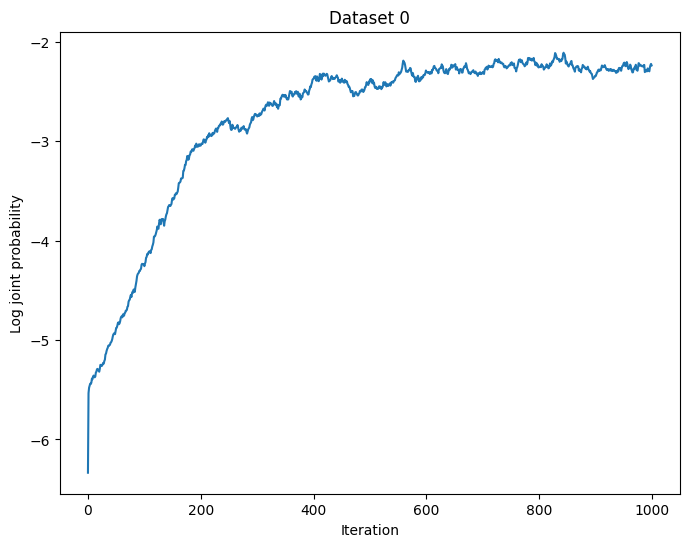

In [62]:
plt.figure(figsize=(8, 6))
plt.plot(jnp.stack(lps[dataset])/emissions[dataset].size) # normalized log joint prob
plt.title(r"Dataset {:d}".format(dataset))
plt.xlabel("Iteration")
plt.ylabel("Log joint probability")
plt.show()

## Estimated criterion fluctuations

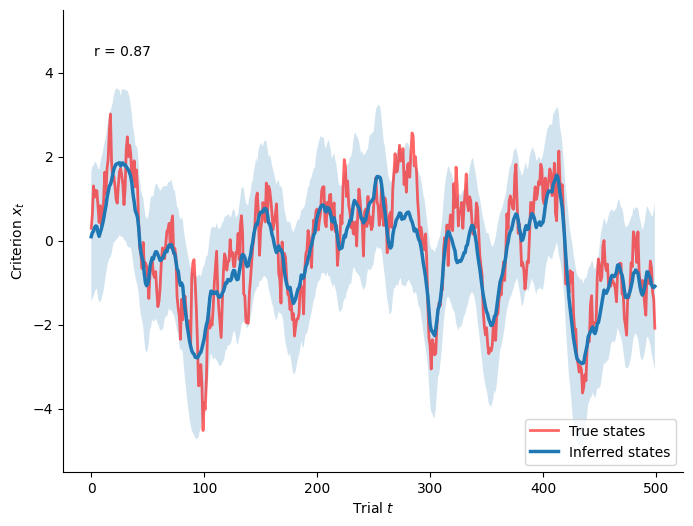

In [80]:
subject = 0

posterior_states_mean = jnp.mean(posterior_samples_states[dataset,burn_in:,subject,:], axis=0)
posterior_states_sd = jnp.std(posterior_samples_states[dataset,burn_in:,subject,:], axis=0)

plt.figure(figsize=(8, 6))
plt.plot(true_states[dataset][subject], label="True states", linewidth=2, color='red', alpha=.6)
plt.plot(posterior_states_mean, label="Inferred states", linewidth=2.5)
plt.fill_between(jnp.arange(num_trials),
          posterior_states_mean - 2 * posterior_states_sd,
          posterior_states_mean + 2 * posterior_states_sd, alpha=0.2)
plt.xlabel("Trial $t$")
plt.ylabel("Criterion $x_t$")
plt.ylim(-5.5,5.5)
plt.legend(loc='lower right')
r, p = spearmanr(true_states[dataset][subject], posterior_states_mean)
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.90), xycoords='axes fraction')
sns.despine()
plt.show()

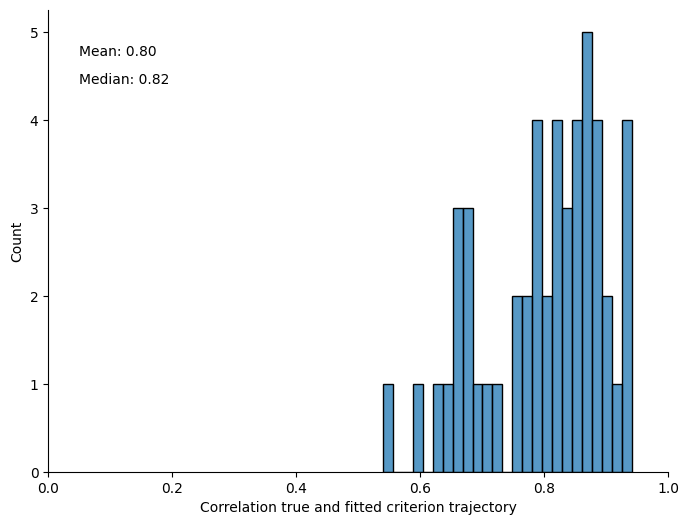

In [78]:
correlations_inferred_and_fitted_states = []

for subject in range(num_subjects):
    r, _= spearmanr(true_states[dataset][subject], jnp.mean(posterior_samples_states[dataset,burn_in:,subject,:], axis=0))
    correlations_inferred_and_fitted_states.append(r)

correlations_inferred_and_fitted_states = jnp.array(correlations_inferred_and_fitted_states)

mean_value = jnp.mean(correlations_inferred_and_fitted_states)
median_value = jnp.median(correlations_inferred_and_fitted_states)

plt.figure(figsize=(8, 6))
sns.histplot(data=correlations_inferred_and_fitted_states, bins=25)
plt.annotate(f'Mean: {mean_value:.2f}', xy=(0.05, 0.90), xycoords='axes fraction')
plt.annotate(f'Median: {median_value:.2f}', xy=(0.05, 0.84), xycoords='axes fraction')
plt.xlabel('Correlation true and fitted criterion trajectory')
plt.ylabel('Count')
plt.xlim(0,1)
sns.despine()
plt.show()

# Per-subject parameters

## Compare true and inferred estimates of $a_i$

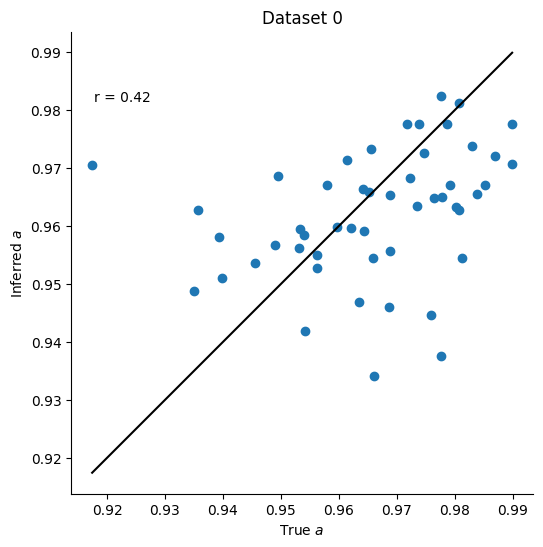

In [94]:
dataset = 0

a_min = min(true_params['a'][dataset].min(), jnp.mean(posterior_samples_a[dataset][burn_in:], axis=0).min())
a_max = max(true_params['a'][dataset].max(), jnp.mean(posterior_samples_a[dataset][burn_in:], axis=0).max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params['a'][dataset], jnp.mean(posterior_samples_a[dataset][burn_in:], axis=0))
plt.plot([a_min, a_max], [a_min, a_max], '-k')
plt.xlabel("True $a$")
plt.ylabel("Inferred $a$")
plt.title(r"Dataset {:d}".format(dataset))
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params['a'][dataset], jnp.mean(posterior_samples_a[dataset][burn_in:], axis=0))
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
sns.despine()
plt.show()
        

## Compare true and inferred estimates of $\sigma^2_i$

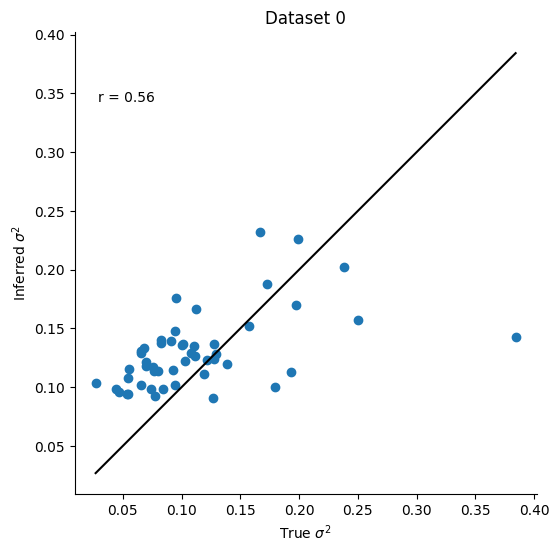

In [96]:
sigmasq_min = min(true_params['sigmasq'][dataset].min(), jnp.mean(posterior_samples_sigmasq[dataset][burn_in:], axis=0).min())
sigmasq_max = max(true_params['sigmasq'][dataset].max(), jnp.mean(posterior_samples_sigmasq[dataset][burn_in:], axis=0).max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params['sigmasq'][dataset], jnp.mean(posterior_samples_sigmasq[dataset][burn_in:], axis=0))
plt.plot([sigmasq_min, sigmasq_max], [sigmasq_min, sigmasq_max], '-k')
plt.xlabel("True $\sigma^2$")
plt.ylabel("Inferred $\sigma^2$")
plt.title(r"Dataset {:d}".format(dataset))
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params['sigmasq'][dataset], jnp.mean(posterior_samples_sigmasq[dataset][burn_in:], axis=0))
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
sns.despine()
plt.show()


## Compare true and inferred estimates of $\mu_{0,i}$

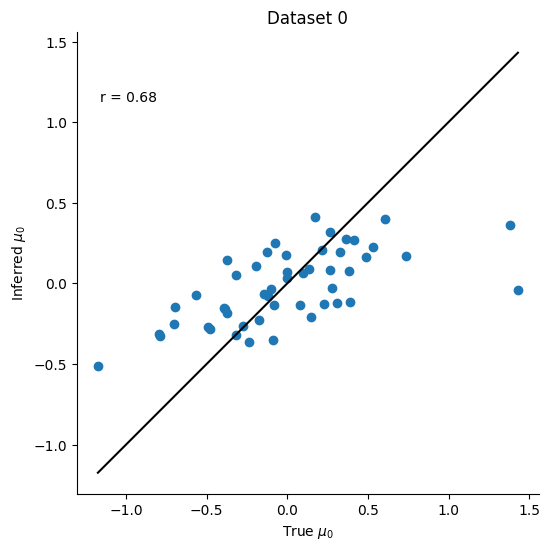

In [97]:
mu0_min = min(true_params['mu0'][dataset].min(), jnp.mean(posterior_samples_mu0[dataset][burn_in:], axis=0).min())
mu0_max = max(true_params['mu0'][dataset].max(), jnp.mean(posterior_samples_mu0[dataset][burn_in:], axis=0).max())

plt.figure(figsize=(8, 6))
plt.scatter(true_params['mu0'][dataset], jnp.mean(posterior_samples_mu0[dataset][burn_in:], axis=0))
plt.plot([mu0_min, mu0_max], [mu0_min, mu0_max], '-k')
plt.xlabel("True $\mu_0$")
plt.ylabel("Inferred $\mu_0$")
plt.title(r"Dataset {:d}".format(dataset))
plt.gca().set_aspect(1.0)
r, p = spearmanr(true_params['mu0'][dataset], jnp.mean(posterior_samples_mu0[dataset][burn_in:], axis=0))
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
sns.despine()
plt.show()
    

## Compare true and inferred estimates of $w_i$

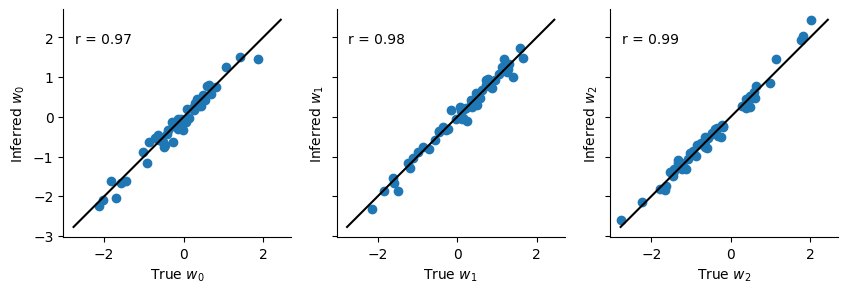

In [103]:
w_min = min(true_params["w"][dataset].min(), jnp.mean(posterior_samples_w[dataset][burn_in:,:,:], axis=0).min())
w_max = max(true_params["w"][dataset].max(), jnp.mean(posterior_samples_w[dataset][burn_in:,:,:], axis=0).max())

fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(10, 5))

for d, ax in enumerate(axs):
    ax.scatter(true_params["w"][dataset,:, d], jnp.mean(posterior_samples_w[dataset][burn_in:,:,d], axis=0))
    ax.set_xlabel(r"True $w_{:d}$".format(d))
    ax.set_ylabel(r"Inferred $w_{:d}$".format(d))
    ax.plot([w_min, w_max], [w_min, w_max], '-k')
    ax.set_aspect(1.0)
    r, p = spearmanr(true_params["w"][dataset,:, d], jnp.mean(posterior_samples_w[dataset][burn_in:,:,d], axis=0))
    ax.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.85), xycoords='axes fraction')
    sns.despine()

## TODO: add rest of plots